# Finite Difference Analysis of a Rectangular Plate  
with Three Simply-Supported Sides and One Clamped Side  
Under a Central Point Load  

**Theory of Plates – Term Project**  
Devanshu Pratap Singh (2511ST02)  

---

## 1 Introduction

The aim of this project is to:

- Derive the governing differential equation for plate bending using Kirchhoff thin plate theory.
- State the boundary conditions for simply supported and clamped edges.
- Discretise the governing equation using the finite difference method (FDM) on a uniform grid.
- Implement the formulation in Python and solve the resulting linear system.
- Perform a convergence study and discuss contour plots of deflection, bending moments, and shear forces.

---

## 2 Governing Equation of Plate Bending

### 2.1 Kirchhoff thin plate theory

The plate flexural rigidity \(D\) is

$$
D = \frac{E h^3}{12\left(1 - \nu^2\right)} \tag{1}
$$

where \(E\) is Young’s modulus, \(\nu\) is Poisson’s ratio, and \(h\) is the plate thickness.

The equilibrium of moments and forces in the plate leads to the biharmonic governing equation

$$
D \nabla^4 w(x,y) = p(x,y), \tag{2}
$$

where \(w(x,y)\) is the transverse deflection and \(p(x,y)\) is the load per unit area (positive downwards).

The biharmonic operator is defined as

$$
\nabla^4 = \nabla^2 \left( \nabla^2 \right)
= \frac{\partial^4}{\partial x^4}
+ 2 \frac{\partial^4}{\partial x^2 \partial y^2}
+ \frac{\partial^4}{\partial y^4}. \tag{3}
$$

In this problem, the plate is loaded by a concentrated load \(P_0\) at the centre  
\((x_c, y_c) = (a/2, b/2)\). In the continuous setting, this can be represented using Dirac delta functions as

$$
p(x,y) = P_0 \, \delta(x - x_c)\, \delta(y - y_c). \tag{4}
$$

In the discrete formulation (Section 4), this point load is approximated by an equivalent uniform load over the central cell.

---

### 2.2 Bending moments and shear forces

In Kirchhoff plate theory, the bending and twisting moments per unit length are related to the deflection by

$$
M_{xx} = -D \left(
\frac{\partial^2 w}{\partial x^2}
+ \nu \frac{\partial^2 w}{\partial y^2}
\right), \tag{5}
$$

$$
M_{yy} = -D \left(
\frac{\partial^2 w}{\partial y^2}
+ \nu \frac{\partial^2 w}{\partial x^2}
\right), \tag{6}
$$

$$
M_{xy} = -D (1 - \nu)
\frac{\partial^2 w}{\partial x \partial y}. \tag{7}
$$

The Kirchhoff shear resultants are given by

$$
Q_x = \frac{\partial M_{xx}}{\partial x} +
\frac{\partial M_{xy}}{\partial y}, \tag{8}
$$

$$
Q_y = \frac{\partial M_{yy}}{\partial y} +
\frac{\partial M_{xy}}{\partial x}. \tag{9}
$$

In the numerical implementation, these derivatives are approximated by central finite differences applied to the discrete deflection field \(w_{ij}\).

---

## 3 Boundary Conditions

The rectangular plate occupies \(0 \le x \le a\), \(0 \le y \le b\). The bottom edge at \(y = 0\) is taken as clamped, and the other three edges are simply supported.

In the code implementation, the deflection is set to zero on all edges. The clamped behaviour at \(y = 0\) is enforced approximately via a modified finite-difference stencil for the second derivative.

### 3.1 Simply supported edge

For a simply supported edge with outward normal vector \(\mathbf{n} = (n_x, n_y)\), the ideal boundary conditions are

$$
w = 0, \tag{10}
$$

$$
M_n = 0, \tag{11}
$$

where the normal bending moment is

$$
M_n = M_{xx} n_x^2 + M_{yy} n_y^2 + 2 M_{xy} n_x n_y. 
$$

### 3.2 Clamped edge

A clamped edge satisfies

$$
w = 0, \tag{12}
$$

$$
\frac{\partial w}{\partial n} = 0, \tag{13}
$$

where \(\partial / \partial n\) denotes differentiation in the direction of the outward unit normal. For the bottom edge \(y = 0\), this condition reduces to \(\partial w / \partial y = 0\).

---

## 4 Finite Difference Discretisation

### 4.1 Grid and unknowns

The plate domain is discretised using a uniform grid with \(N_x\) nodes in the \(x\)-direction and \(N_y\) nodes in the \(y\)-direction, including the boundary nodes.

For the convergence study, a square grid is used with \(N_x = N_y = N\). The grid spacings are

$$
h_x = \frac{a}{N_x - 1}, \tag{14}
$$

$$
h_y = \frac{b}{N_y - 1}. \tag{15}
$$

The unknowns of the system are the deflections at interior grid points

$$
w_{ij} \approx w(x_i, y_j), \quad
i = 1, \dots, N_x - 2,\quad
j = 1, \dots, N_y - 2, \tag{16}
$$

where \(x_i = i h_x\), \(y_j = j h_y\). The deflection at the boundary nodes is set to zero.

The interior nodal values are stacked into a column vector  
\( \mathbf{w} \in \mathbb{R}^{n_x n_y} \), where \(n_x = N_x - 2\), \(n_y = N_y - 2\).

---

### 4.2 Discrete Laplacian in 1D

In one spatial dimension, the second derivative at an interior node \(i\) is approximated by the central difference formula

$$
\left.\frac{d^2 w}{dx^2}\right|_{x_i}
\approx
\frac{w_{i-1} - 2 w_i + w_{i+1}}{h_x^2}. \tag{17}
$$

The first and last rows of the corresponding finite-difference matrix are modified depending on the boundary type (simply supported or clamped) to approximate the edge conditions.

---

### 4.3 Biharmonic operator

The discrete Laplacian operator in 2D is constructed using 1D second-derivative matrices and Kronecker products. The biharmonic operator \(\nabla^4\) is then approximated by

$$
A = L L, \tag{18}
$$

where \(L\) is the discrete Laplacian operator acting on the vector of interior unknowns.

Thus, the discrete counterpart of the governing equation (2) can be written as

$$
D A \mathbf{w} = \mathbf{p}, \tag{19}
$$

or, equivalently,

$$
A \mathbf{w} = \mathbf{f}, \qquad
\mathbf{f} = \frac{\mathbf{p}}{D}. \tag{20}
$$

---

### 4.4 Approximation of the central point load

The continuous point load \(P_0\) at the plate centre is approximated as a uniformly distributed load over the central cell of area \(h_x h_y\). The equivalent load per unit area is

$$
p_{\text{eff}} = \frac{P_0}{h_x h_y}. \tag{21}
$$

This load is applied at the grid node closest to the centre \((a/2, b/2)\). The corresponding entry in the right-hand side vector \(\mathbf{f}\) is

$$
f_c = \frac{p_{\text{eff}}}{D}
= \frac{P_0}{D \, h_x h_y}. \tag{22}
$$

---

## 5 Post-processing: Moments and Shear Forces

Once the discrete solution for the deflection field \(w_{ij}\) is obtained on the full grid (with zero boundary values), second derivatives are approximated using central differences.

For the curvature terms:

$$
\left.\frac{\partial^2 w}{\partial x^2}\right|_{i,j}
\approx
\frac{w_{i-1,j} - 2 w_{i,j} + w_{i+1,j}}{h_x^2}, \tag{23}
$$

$$
\left.\frac{\partial^2 w}{\partial y^2}\right|_{i,j}
\approx
\frac{w_{i,j-1} - 2 w_{i,j} + w_{i,j+1}}{h_y^2}, \tag{24}
$$

$$
\left.\frac{\partial^2 w}{\partial x \partial y}\right|_{i,j}
\approx
\frac{
w_{i+1,j+1} - w_{i+1,j-1}
- w_{i-1,j+1} + w_{i-1,j-1}
}{4 h_x h_y}. \tag{25}
$$

Substituting these approximations into equations (5)–(7) yields the discrete bending and twisting moment fields \(M_{xx,ij}\), \(M_{yy,ij}\), and \(M_{xy,ij}\).

The shear forces are then obtained by differentiating the discrete moments using central differences, following (8)–(9). For example,

$$
\left.\frac{\partial M_{xx}}{\partial x}\right|_{i,j}
\approx
\frac{M_{xx, i+1,j} - M_{xx, i-1,j}}{2 h_x}, \tag{26}
$$

$$
\left.\frac{\partial M_{xy}}{\partial y}\right|_{i,j}
\approx
\frac{M_{xy, i,j+1} - M_{xy, i,j-1}}{2 h_y}, \tag{27}
$$

and similarly for the derivatives with respect to \(y\).

From these, the discrete shear resultants \(Q_{x,ij}\) and \(Q_{y,ij}\) are computed at all interior nodes and can be visualised using contour plots to analyse the internal force distribution in the plate.

---


Finite Difference Method – Rectangular Plate
BC: 3 edges simply supported (w=0), bottom edge clamped (w=0, slope≈0)
Load: central point load P0 (N)

Convergence at plate centre (x=a/2, y=b/2)
N = total grid points in each direction (including boundaries)

N =   9    P0 =  100000.00 N  Wxy = 7.1828e+02  Mxx = 2.7154e+04  Myy = 2.8886e+04  Mxy = 7.2876e-13  Qxz = -8.7247e-15  Qyz = 5.0475e+00
N =  13    P0 =  100000.00 N  Wxy = 7.3514e+02  Mxx = 3.2038e+04  Myy = 3.3556e+04  Mxy = -9.8383e-12  Qxz = -3.9248e-13  Qyz = 4.2871e+00
N =  17    P0 =  100000.00 N  Wxy = 7.4344e+02  Mxx = 3.5305e+04  Myy = 3.6730e+04  Mxy = 4.0811e-11  Qxz = -3.1576e-13  Qyz = 3.9685e+00
N =  21    P0 =  100000.00 N  Wxy = 7.4873e+02  Mxx = 3.7775e+04  Myy = 3.9145e+04  Mxy = 3.6438e-11  Qxz = -1.3377e-12  Qyz = 3.7939e+00
N =  25    P0 =  100000.00 N  Wxy = 7.5247e+02  Mxx = 3.9763e+04  Myy = 4.1098e+04  Mxy = -3.2794e-10  Qxz = 2.5333e-13  Qyz = 3.6839e+00


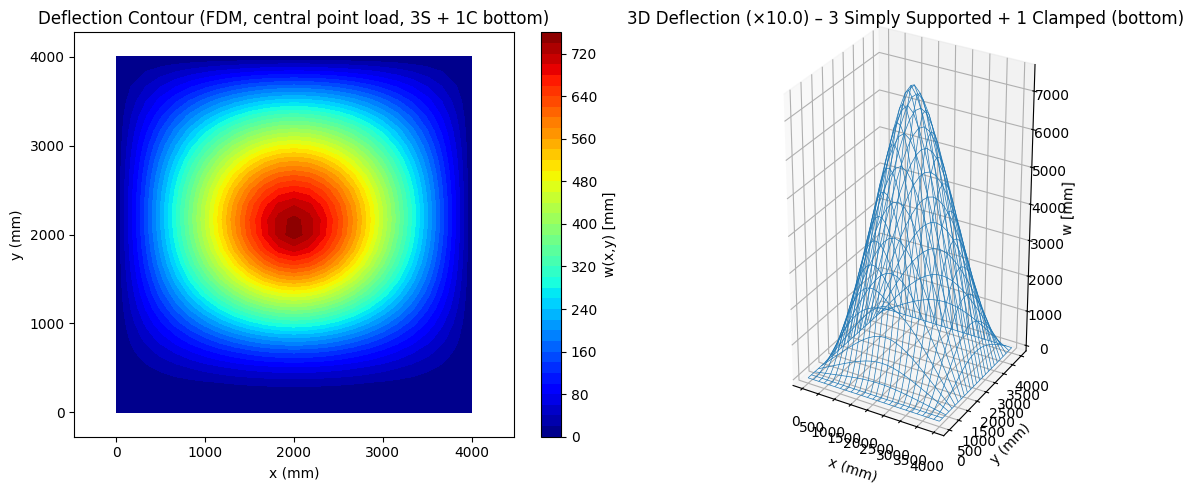

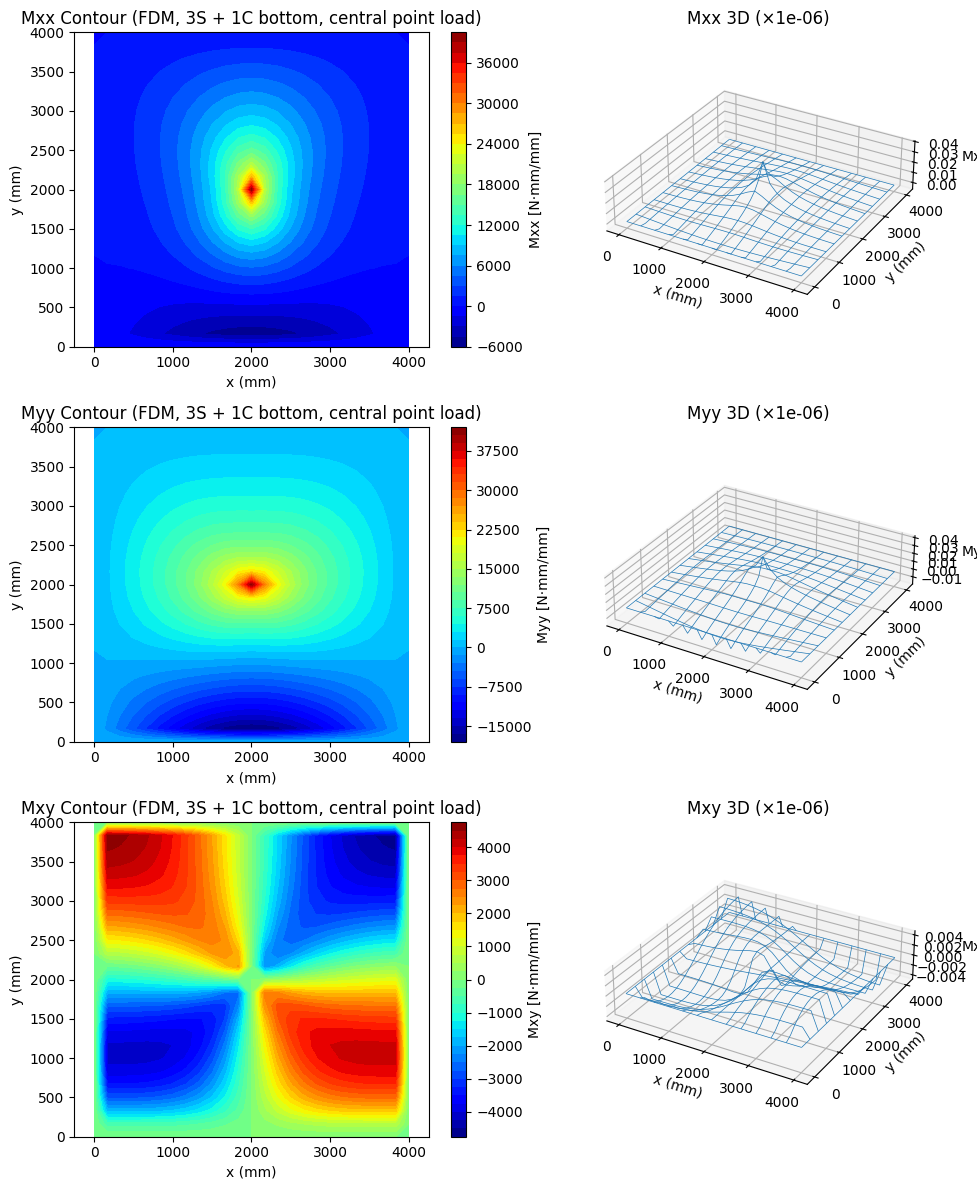

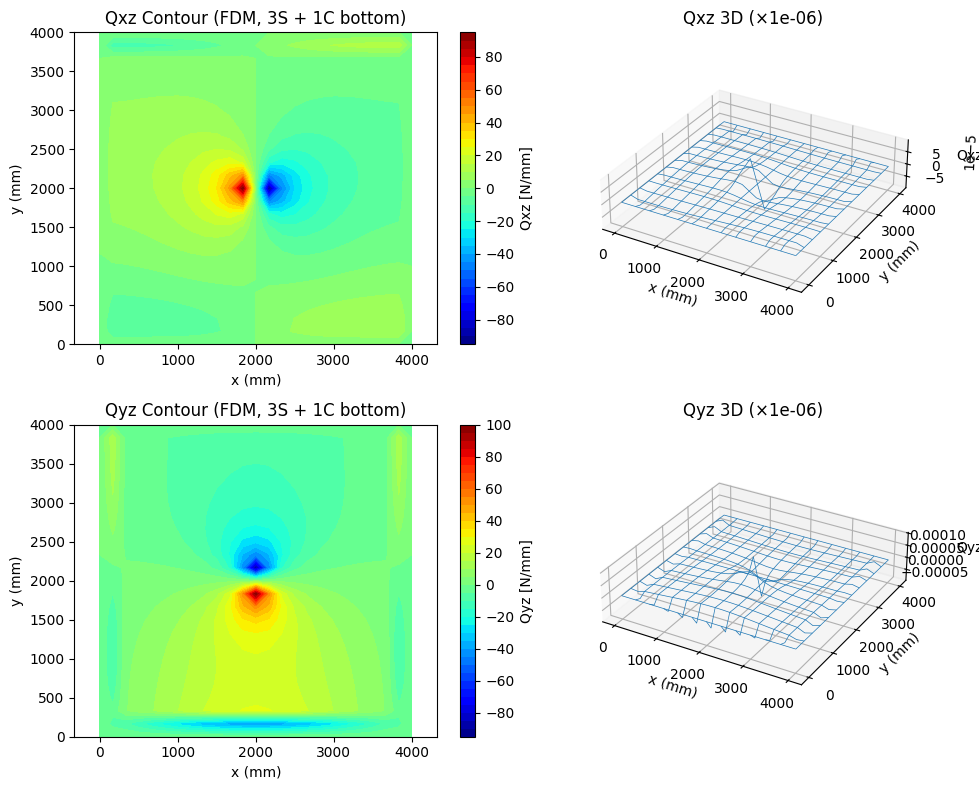

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ----------------------------------------------------- Input -------------------------------------------------
# Material and geometry
E = 200000.0        # MPa
nu = 0.3            # Poisson's ratio

# Plate dimensions (mm)
a = 4000.0          # length in x
b = 4000.0          # length in y
h = 10.0            # thickness

# Central point load (N)
P0 = 1.0e5          # you can change this

# ----------------------- CONSTANTS ------------------------
pi = np.pi
D = E * h**3 / (12.0 * (1.0 - nu**2))     # flexural rigidity (N·mm)


# -------------------------------------------------------------------------------------------------------------
# Build full-grid biharmonic operator A ≈ ∇^4 using L @ L
# Unknowns: ALL nodes (including boundaries)
# -------------------------------------------------------------------------------------------------------------
def build_biharmonic_full(Nx, Ny, a, b):
    """
    Build the ∇^4 operator on an Nx × Ny full grid (including boundaries).
    We first build a full-grid Laplacian L and then set A = L @ L.

    NOTE:
    - Boundary rows of A will later be overwritten to impose the desired BCs.
    """
    hx = a / (Nx - 1)
    hy = b / (Ny - 1)

    # 1D second-derivative matrices with placeholder Dirichlet rows
    Tx = np.zeros((Nx, Nx))
    for i in range(Nx):
        if i == 0 or i == Nx - 1:
            # boundary rows will be overwritten later anyway
            Tx[i, i] = 1.0
        else:
            Tx[i, i] = -2.0
            Tx[i, i - 1] = 1.0
            Tx[i, i + 1] = 1.0
    Tx /= hx**2

    Ty = np.zeros((Ny, Ny))
    for j in range(Ny):
        if j == 0 or j == Ny - 1:
            Ty[j, j] = 1.0
        else:
            Ty[j, j] = -2.0
            Ty[j, j - 1] = 1.0
            Ty[j, j + 1] = 1.0
    Ty /= hy**2

    Ix = np.eye(Nx)
    Iy = np.eye(Ny)

    # 2D Laplacian on full grid
    L = np.kron(Iy, Tx) + np.kron(Ty, Ix)

    # Biharmonic operator
    A = L @ L

    return A, hx, hy


# -------------------------------------------------------------------------------------------------------------
# Apply boundary conditions: 3 simply supported, 1 clamped (bottom)
# -------------------------------------------------------------------------------------------------------------
def apply_3S_1C_bc(A, rhs, Nx, Ny, hx, hy, clamped_edge="bottom"):
    """
    Modify matrix A and rhs to impose:
      - three simply supported edges: w = 0
      - one clamped edge: w = 0 and slope normal = 0 (approx).

    Here, simply supported is approximated as w=0 only.
    Clamped is enforced numerically by:
        w(boundary) = 0
        (w(first interior) - w(boundary))/h = 0  -> zero slope
    """
    # Helper to convert (i, j) -> 1D index (row-major)
    def idx(i, j):
        return j * Nx + i

    # ----- Choose which edge is clamped -----
    # Options: "bottom", "top", "left", "right"
    clamped_edge = clamped_edge.lower()

    # --- 1) First apply simply-supported: w = 0 on ALL four edges
    # Then adjust the chosen edge to be clamped (add slope condition).
    for i in range(Nx):
        # bottom j=0
        k = idx(i, 0)
        A[k, :] = 0.0
        A[k, k] = 1.0
        rhs[k] = 0.0

        # top j=Ny-1
        k = idx(i, Ny - 1)
        A[k, :] = 0.0
        A[k, k] = 1.0
        rhs[k] = 0.0

    for j in range(Ny):
        # left i=0
        k = idx(0, j)
        A[k, :] = 0.0
        A[k, k] = 1.0
        rhs[k] = 0.0

        # right i=Nx-1
        k = idx(Nx - 1, j)
        A[k, :] = 0.0
        A[k, k] = 1.0
        rhs[k] = 0.0

    # --- 2) Now add clamped (zero slope) condition on selected edge ---
    if clamped_edge == "bottom":
        # y = 0 is clamped: w=0 (already done) and ∂w/∂y ≈ 0
        # enforce slope = 0 at first interior row j=1:
        #   (w(i,1) - w(i,0))/hy = 0
        for i in range(Nx):
            k1 = idx(i, 1)
            k0 = idx(i, 0)
            A[k1, :] = 0.0
            A[k1, k1] = 1.0 / hy
            A[k1, k0] = -1.0 / hy
            rhs[k1] = 0.0

    elif clamped_edge == "top":
        # y = b (j = Ny-1): slope at j=Ny-2 ≈ 0
        for i in range(Nx):
            k_in = idx(i, Ny - 2)
            k_b = idx(i, Ny - 1)
            A[k_in, :] = 0.0
            A[k_in, k_in] = 1.0 / hy
            A[k_in, k_b] = -1.0 / hy
            rhs[k_in] = 0.0

    elif clamped_edge == "left":
        # x = 0 (i = 0): slope at i=1 ≈ 0
        for j in range(Ny):
            k1 = idx(1, j)
            k0 = idx(0, j)
            A[k1, :] = 0.0
            A[k1, k1] = 1.0 / hx
            A[k1, k0] = -1.0 / hx
            rhs[k1] = 0.0

    elif clamped_edge == "right":
        # x = a (i = Nx-1): slope at i=Nx-2 ≈ 0
        for j in range(Ny):
            k_in = idx(Nx - 2, j)
            k_b = idx(Nx - 1, j)
            A[k_in, :] = 0.0
            A[k_in, k_in] = 1.0 / hx
            A[k_in, k_b] = -1.0 / hx
            rhs[k_in] = 0.0

    else:
        raise ValueError("clamped_edge must be 'bottom', 'top', 'left', or 'right'.")


# -------------------------------------------------------------------------------------------------------------
# Convergence study for 3 SS + 1 clamped (bottom)
# -------------------------------------------------------------------------------------------------------------
N_list = [9, 13, 17, 21, 25]   # total nodes per direction (including boundaries)

Pxy_vals = []
Wxy_vals = []
Mxx_vals = []
Myy_vals = []
Mxy_vals = []
Qxz_vals = []
Qyz_vals = []

for N in N_list:
    Nx = Ny = N
    A, hx, hy = build_biharmonic_full(Nx, Ny, a, b)

    # RHS: central point load approximated over central cell
    rhs = np.zeros(Nx * Ny)

    ic = Nx // 2
    jc = Ny // 2
    centre_idx = jc * Nx + ic
    rhs[centre_idx] = P0 / (D * hx * hy)

    # Impose 3S + 1C BC (bottom clamped)
    apply_3S_1C_bc(A, rhs, Nx, Ny, hx, hy, clamped_edge="bottom")

    # Solve
    w_vec = np.linalg.solve(A, rhs)

    # Reshape to full field
    W = w_vec.reshape((Ny, Nx))

    # Centre values
    W_c = W[jc, ic]

    # Compute derivatives for moments/shears
    d2wdx2 = np.zeros_like(W)
    d2wdy2 = np.zeros_like(W)

    d2wdx2[:, 1:-1] = (W[:, 0:-2] - 2.0 * W[:, 1:-1] + W[:, 2:]) / hx**2
    d2wdy2[1:-1, :] = (W[0:-2, :] - 2.0 * W[1:-1, :] + W[2:, :]) / hy**2

    d2wdxdy = np.zeros_like(W)
    d2wdxdy[1:-1, 1:-1] = (
        W[2:, 2:] - W[2:, 0:-2] - W[0:-2, 2:] + W[0:-2, 0:-2]
    ) / (4.0 * hx * hy)

    Mxx = -D * (d2wdx2 + nu * d2wdy2)
    Myy = -D * (d2wdy2 + nu * d2wdx2)
    Mxy = -D * (1.0 - nu) * d2wdxdy

    dMxxdx = np.zeros_like(W)
    dMxydy = np.zeros_like(W)
    dMyydy = np.zeros_like(W)
    dMxydx = np.zeros_like(W)

    dMxxdx[:, 1:-1] = (Mxx[:, 2:] - Mxx[:, 0:-2]) / (2.0 * hx)
    dMxydy[1:-1, :] = (Mxy[2:, :] - Mxy[0:-2, :]) / (2.0 * hy)
    dMyydy[1:-1, :] = (Myy[2:, :] - Myy[0:-2, :]) / (2.0 * hy)
    dMxydx[:, 1:-1] = (Mxy[:, 2:] - Mxy[:, 0:-2]) / (2.0 * hx)

    Qxz = dMxxdx + dMxydy
    Qyz = dMyydy + dMxydx

    Mxx_c = Mxx[jc, ic]
    Myy_c = Myy[jc, ic]
    Mxy_c = Mxy[jc, ic]
    Qxz_c = Qxz[jc, ic]
    Qyz_c = Qyz[jc, ic]

    Pxy_vals.append(P0)
    Wxy_vals.append(W_c)
    Mxx_vals.append(Mxx_c)
    Myy_vals.append(Myy_c)
    Mxy_vals.append(Mxy_c)
    Qxz_vals.append(Qxz_c)
    Qyz_vals.append(Qyz_c)

# --- Output convergence table ---
print("Finite Difference Method – Rectangular Plate")
print("BC: 3 edges simply supported (w=0), bottom edge clamped (w=0, slope≈0)")
print("Load: central point load P0 (N)\n")

print("Convergence at plate centre (x=a/2, y=b/2)")
print("N = total grid points in each direction (including boundaries)\n")
for N, P1, W1, M11, M22, M12, Q13, Q23 in zip(
        N_list, Pxy_vals, Wxy_vals, Mxx_vals, Myy_vals, Mxy_vals, Qxz_vals, Qyz_vals):
    print(f"N = {N:3d}    P0 = {P1:10.2f} N  Wxy = {W1:10.4e}  "
          f"Mxx = {M11:10.4e}  Myy = {M22:10.4e}  Mxy = {M12:10.4e}  "
          f"Qxz = {Q13:10.4e}  Qyz = {Q23:10.4e}")

# -------------------------------------------------------------------------------------------------------------
# Full-field plots for finest grid
# -------------------------------------------------------------------------------------------------------------
N_plot = N_list[-1]
Nx = Ny = N_plot
A, hx, hy = build_biharmonic_full(Nx, Ny, a, b)
rhs = np.zeros(Nx * Ny)

ic = Nx // 2
jc = Ny // 2
centre_idx = jc * Nx + ic
rhs[centre_idx] = P0 / (D * hx * hy)

apply_3S_1C_bc(A, rhs, Nx, Ny, hx, hy, clamped_edge="bottom")

w_vec = np.linalg.solve(A, rhs)
W = w_vec.reshape((Ny, Nx))

# Recompute derivatives, moments, and shears
d2wdx2 = np.zeros_like(W)
d2wdy2 = np.zeros_like(W)

d2wdx2[:, 1:-1] = (W[:, 0:-2] - 2.0 * W[:, 1:-1] + W[:, 2:]) / hx**2
d2wdy2[1:-1, :] = (W[0:-2, :] - 2.0 * W[1:-1, :] + W[2:, :]) / hy**2

d2wdxdy = np.zeros_like(W)
d2wdxdy[1:-1, 1:-1] = (
    W[2:, 2:] - W[2:, 0:-2] - W[0:-2, 2:] + W[0:-2, 0:-2]
) / (4.0 * hx * hy)

Mxx = -D * (d2wdx2 + nu * d2wdy2)
Myy = -D * (d2wdy2 + nu * d2wdx2)
Mxy = -D * (1.0 - nu) * d2wdxdy

dMxxdx = np.zeros_like(W)
dMxydy = np.zeros_like(W)
dMyydy = np.zeros_like(W)
dMxydx = np.zeros_like(W)

dMxxdx[:, 1:-1] = (Mxx[:, 2:] - Mxx[:, 0:-2]) / (2.0 * hx)
dMxydy[1:-1, :] = (Mxy[2:, :] - Mxy[0:-2, :]) / (2.0 * hy)
dMyydy[1:-1, :] = (Myy[2:, :] - Myy[0:-2, :]) / (2.0 * hy)
dMxydx[:, 1:-1] = (Mxy[:, 2:] - Mxy[:, 0:-2]) / (2.0 * hx)

Qxz = dMxxdx + dMxydy
Qyz = dMyydy + dMxydx

# Grid for plotting
x_coords = np.linspace(0, a, Nx)
y_coords = np.linspace(0, b, Ny)
Xg, Yg = np.meshgrid(x_coords, y_coords)

# ------------------------------------ Deflection plots ------------------------------------
z_scale = 10.0  # purely for visual exaggeration
Z = W * z_scale

fig = plt.figure(figsize=(12, 5))

# Contour of deflection
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(x_coords, y_coords, W, 40, cmap='jet')
fig.colorbar(cp, ax=ax1, label='w(x,y) [mm]')
ax1.set_title('Deflection Contour (FDM, central point load, 3S + 1C bottom)')
ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.axis('equal')

# 3D wireframe
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_wireframe(Xg, Yg, Z, linewidth=0.5)
ax2.set_title(f'3D Deflection (×{z_scale}) – 3 Simply Supported + 1 Clamped (bottom)')
ax2.set_xlabel('x (mm)')
ax2.set_ylabel('y (mm)')
ax2.set_zlabel('w [mm]')
ax2.set_box_aspect([a, b, np.max(Z) - np.min(Z)])

plt.tight_layout()
plt.show()

# ------------------------------------ Moment plots ------------------------------------
z_scale_m = 1e-6
fields = [Mxx, Myy, Mxy]
titles = ['Mxx', 'Myy', 'Mxy']

fig = plt.figure(figsize=(10, 12))
for k, (F, t) in enumerate(zip(fields, titles)):
    F = np.array(F)
    Zm = F * z_scale_m

    ax1 = fig.add_subplot(3, 2, 2*k + 1)
    c = ax1.contourf(x_coords, y_coords, F, 40, cmap='jet')
    fig.colorbar(c, ax=ax1, label=f'{t} [N·mm/mm]')
    ax1.set_title(f'{t} Contour (FDM, 3S + 1C bottom, central point load)')
    ax1.set_xlabel('x (mm)')
    ax1.set_ylabel('y (mm)')
    ax1.axis('equal')

    ax2 = fig.add_subplot(3, 2, 2*k + 2, projection='3d')
    ax2.plot_wireframe(Xg, Yg, Zm, lw=0.5, rstride=2, cstride=2)
    ax2.set_title(f'{t} 3D (×{z_scale_m})')
    ax2.set_xlabel('x (mm)')
    ax2.set_ylabel('y (mm)')
    ax2.set_zlabel(t)
    ax2.set_box_aspect([a, b, 0.25 * max(a, b)])

plt.tight_layout()
plt.show()

# ------------------------------------ Shear plots ------------------------------------
z_scale_q = 1e-6
fields_q = [Qxz, Qyz]
titles_q = ['Qxz', 'Qyz']

fig = plt.figure(figsize=(10, 8))
for k, (F, t) in enumerate(zip(fields_q, titles_q)):
    F = np.array(F)
    Zq = F * z_scale_q

    ax1 = fig.add_subplot(2, 2, 2*k + 1)
    c = ax1.contourf(x_coords, y_coords, F, 40, cmap='jet')
    fig.colorbar(c, ax=ax1, label=f'{t} [N/mm]')
    ax1.set_title(f'{t} Contour (FDM, 3S + 1C bottom)')
    ax1.set_xlabel('x (mm)')
    ax1.set_ylabel('y (mm)')
    ax1.axis('equal')

    ax2 = fig.add_subplot(2, 2, 2*k + 2, projection='3d')
    ax2.plot_wireframe(Xg, Yg, Zq, lw=0.5, rstride=2, cstride=2)
    ax2.set_title(f'{t} 3D (×{z_scale_q})')
    ax2.set_xlabel('x (mm)')
    ax2.set_ylabel('y (mm)')
    ax2.set_zlabel(t)
    ax2.set_box_aspect([a, b, 0.25 * max(a, b)])

plt.tight_layout()
plt.show()
